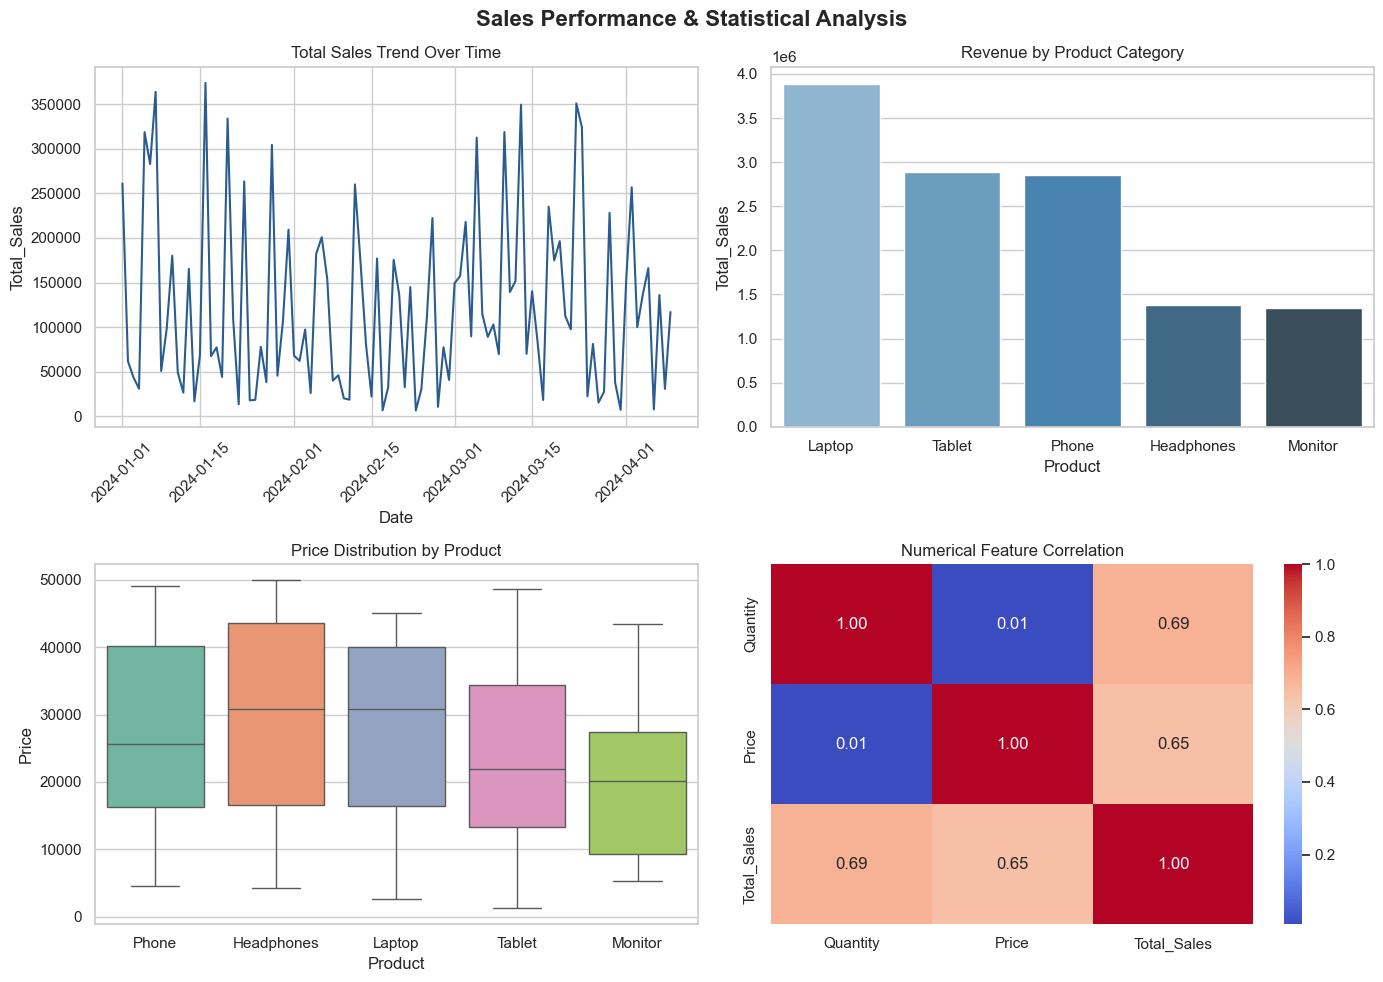

Saved grid visualization to 'visualizations/dashboard_grid.png'


In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create visualizations folder if it doesn't exist
os.makedirs("visualizations", exist_ok=True)

# Loading dataset
df = pd.read_csv("sales_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Set global Seaborn theme /--
sns.set_theme(style="whitegrid", palette="muted")

# --- Day 1 & Day 4: Multi-plot Dashboard Grid (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Sales Performance & Statistical Analysis", fontsize=16, fontweight="bold"
)

# Plot 1: Sales Trend over Time
df_trend = df.groupby("Date")["Total_Sales"].sum().reset_index()
sns.lineplot(
    data=df_trend, x="Date", y="Total_Sales", ax=axes[0, 0], color="#2b5c8f"
)
axes[0, 0].set_title("Total Sales Trend Over Time")
axes[0, 0].tick_params(axis="x", rotation=45)

# Plot 2: Total Sales by Product
df_product = (
    df.groupby("Product")["Total_Sales"].sum().reset_index().sort_values(
        by="Total_Sales", ascending=False
    )
)
sns.barplot(
    data=df_product,
    x="Product",
    y="Total_Sales",
    hue = "Product",
    legend = False,
    ax=axes[0, 1],
    palette="Blues_d",
)
axes[0, 1].set_title("Revenue by Product Category")

# Plot 3: Box Plot of Price Distribution
sns.boxplot(
    data=df, x="Product", y="Price", ax=axes[1, 0], palette="Set2",
    hue = "Product",legend = False
)
axes[1, 0].set_title("Price Distribution by Product")

# Plot 4: Correlation Heatmap
numeric_cols = ["Quantity", "Price", "Total_Sales"]
corr = df[numeric_cols].corr()
sns.heatmap(
    corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1], cbar=True
)
axes[1, 1].set_title("Numerical Feature Correlation")

plt.tight_layout()
plt.savefig("visualizations/dashboard_grid.png", dpi=300)
plt.show()
print("Saved grid visualization to 'visualizations/dashboard_grid.png'")